In [4]:
# Package imports
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Dataframe
import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic plot
import seaborn as sns                               # Advanced dataviz

## Question 1

The data frame below shows the evolution of the average duration of a first marriage in Belgium, since 2015 by type of marriage (male-female / female-female / male-male) (Source: StatBel). Can we say that a man-man marriage lasts significantly longer than a woman-woman marriage?  
Make a plot!



In [5]:
divorces = pd.DataFrame(data={
    'year': [2015,2016,2017,2018,2019,2020,2021,2022,2023],
    'm_f': [16.7, 16.9, 16.9, 16.7, 16.7, 16.4, 16.6, 16.7, 16.1],
    'f_f': [5.5, 6.4, 6.3, 7.4, 6.7, 6.7, 7.0, 7.8, 8.0],
    'm_m': [6.0, 6.3, 6.9, 7.4, 7.4, 8.0, 8.2, 8.2, 8.5]
}).set_index('year')
divorces.head()

,m_f,f_f,m_m
year,,,
2015,16.7,5.5,6.0
2016,16.9,6.4,6.3
2017,16.9,6.3,6.9
2018,16.7,7.4,7.4
2019,16.7,6.7,7.4


### Plotting the evolution of marriage duration for man-man and woman-woman marriages

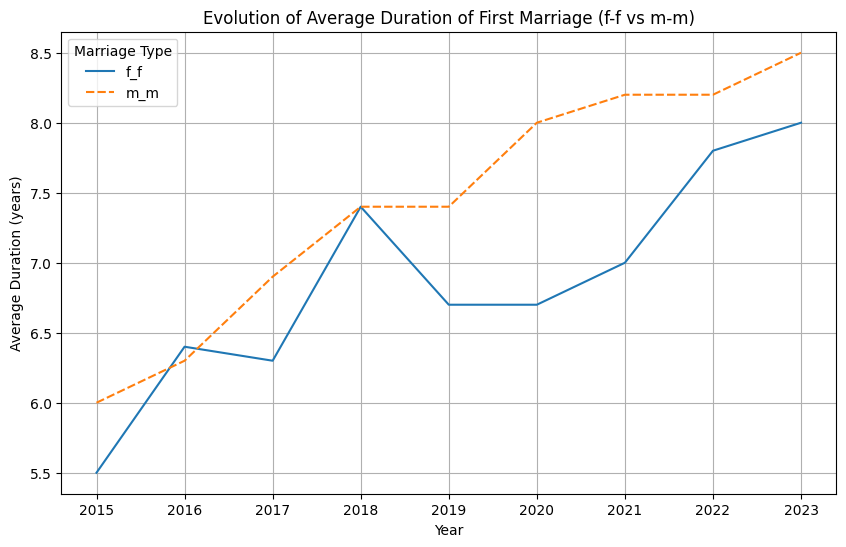

In [6]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=divorces[['f_f', 'm_m']])
plt.title('Evolution of Average Duration of First Marriage (f-f vs m-m)')
plt.xlabel('Year')
plt.ylabel('Average Duration (years)')
plt.legend(title='Marriage Type')
plt.grid(True)
plt.show()

The plot shows an increasing trend for both 'f_f' and 'm_m' marriage durations. Visually, 'm_m' appears to be generally higher than 'f_f', especially in later years. To determine if this difference is statistically significant, we will perform a paired t-test. A paired t-test is appropriate here because the observations for 'f_f' and 'm_m' are taken in the same years, making them dependent samples.

In [7]:
# Perform a paired t-test
t_statistic, p_value = stats.ttest_rel(divorces['m_m'], divorces['f_f'], alternative='greater')

print(f"Paired t-test results:\nT-statistic: {t_statistic:.3f}\nP-value: {p_value:.3f}")

alpha = 0.05
if p_value < alpha:
    print(f"Since the p-value ({p_value:.3f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("Conclusion: A man-man marriage lasts significantly longer than a woman-woman marriage.")
else:
    print(f"Since the p-value ({p_value:.3f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("Conclusion: We do not have sufficient evidence to say that a man-man marriage lasts significantly longer than a woman-woman marriage.")

Paired t-test results:
T-statistic: 3.624
P-value: 0.003
Since the p-value (0.003) is less than the significance level (0.05), we reject the null hypothesis.
Conclusion: A man-man marriage lasts significantly longer than a woman-woman marriage.


## Question 2

The data frame below shows the evolution of the average duration of a first and a subsequent marriage in Belgium since 2015 (Source: StatBel). Can we say that a first marriage lasts significantly longer than a subsequent marriage? Make a plot!


In [8]:
divorces = pd.DataFrame(data={
    'year': [2015,2016,2017,2018,2019,2020,2021,2022,2023],
    'first_marriage': [16.7, 16.9, 16.9, 16.7, 16.7, 16.4, 16.6, 16.7, 16.1],
    'subsequent_marriage': [10.5, 11.0, 11.2, 11.3, 11.3, 11.4, 11.5, 11.9, 11.8]
}).set_index('year')
divorces.head()

,first_marriage,subsequent_marriage
year,,
2015,16.7,10.5
2016,16.9,11.0
2017,16.9,11.2
2018,16.7,11.3
2019,16.7,11.3


### Plotting the evolution of first marriage vs. subsequent marriage durations

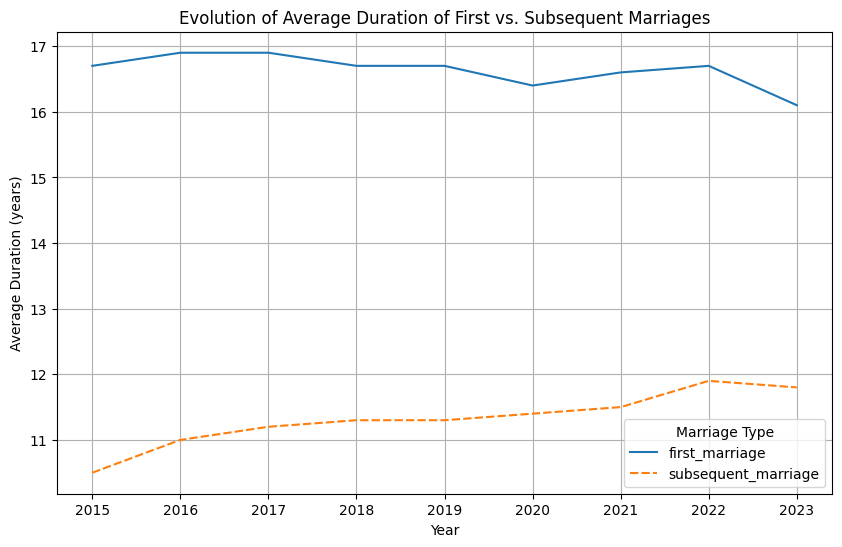

In [10]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=divorces[['first_marriage', 'subsequent_marriage']])
plt.title('Evolution of Average Duration of First vs. Subsequent Marriages')
plt.xlabel('Year')
plt.ylabel('Average Duration (years)')
plt.legend(title='Marriage Type')
plt.grid(True)
plt.show()

The plot clearly shows that 'first_marriage' durations are consistently higher than 'subsequent_marriage' durations. To confirm if this difference is statistically significant, a paired t-test is appropriate, as the data for both types of marriages is collected over the same years.

In [11]:
# Perform a paired t-test
t_statistic, p_value = stats.ttest_rel(divorces['first_marriage'], divorces['subsequent_marriage'], alternative='greater')

print(f"Paired t-test results:\nT-statistic: {t_statistic:.3f}\nP-value: {p_value:.3f}")

alpha = 0.05
if p_value < alpha:
    print(f"Since the p-value ({p_value:.3f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("Conclusion: A first marriage lasts significantly longer than a subsequent marriage.")
else:
    print(f"Since the p-value ({p_value:.3f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("Conclusion: We do not have sufficient evidence to say that a first marriage lasts significantly longer than a subsequent marriage.")

Paired t-test results:
T-statistic: 27.281
P-value: 0.000
Since the p-value (0.000) is less than the significance level (0.05), we reject the null hypothesis.
Conclusion: A first marriage lasts significantly longer than a subsequent marriage.


## Question 3
A local pizzeria claims that they can deliver pizza faster than a local branch of a large chain. To verify this, you ordered pizza from both of them 10 times. Below are the times (in minutes) they took. Can the local pizzeria indeed deliver pizzas significantly faster than the big player? Make a plot.



In [9]:
dfpizzas = pd.DataFrame(data= {'local': [16.8, 11.7, 15.6, 16.7, 17.5, 18.1, 14.1, 21.8, 13.9, 20.8],
                               'chain': [22.0, 15.2, 18.7, 15.6, 20.8, 19.5, 17.0, 19.5, 16.5, 24.0]})
dfpizzas.head()

,local,chain
0,16.8,22.0
1,11.7,15.2
2,15.6,18.7
3,16.7,15.6
4,17.5,20.8


### Plotting pizza delivery times for local vs. chain pizzerias

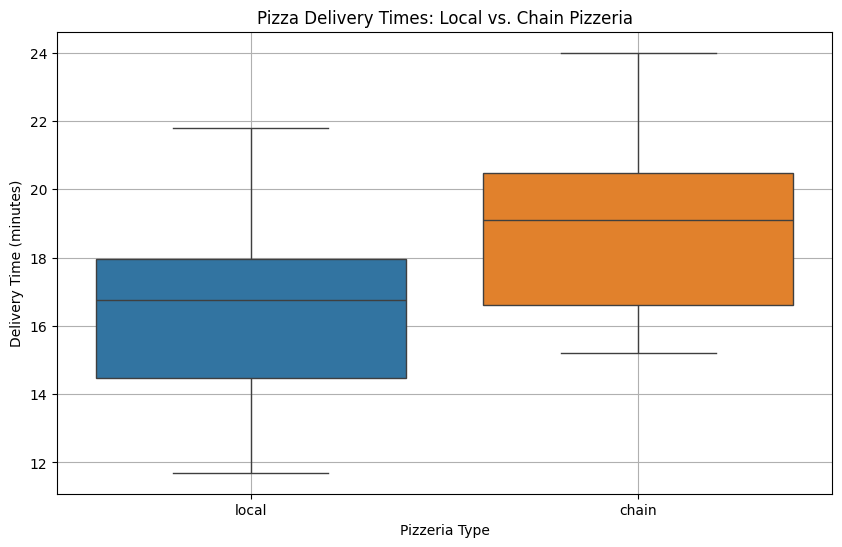

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=dfpizzas[['local', 'chain']])
plt.title('Pizza Delivery Times: Local vs. Chain Pizzeria')
plt.xlabel('Pizzeria Type')
plt.ylabel('Delivery Time (minutes)')
plt.grid(True)
plt.show()

The box plot provides a visual comparison of the delivery times. To statistically determine if the local pizzeria delivers significantly faster, a paired t-test is appropriate. Since the orders were placed 10 times from both, these are dependent samples. We'll test if 'local' delivery times are significantly less than 'chain' delivery times.

In [13]:
# Perform a paired t-test to check if local is faster (i.e., local < chain)
t_statistic, p_value = stats.ttest_rel(dfpizzas['local'], dfpizzas['chain'], alternative='less')

print(f"Paired t-test results:\nT-statistic: {t_statistic:.3f}\nP-value: {p_value:.3f}")

alpha = 0.05
if p_value < alpha:
    print(f"Since the p-value ({p_value:.3f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("Conclusion: The local pizzeria delivers pizzas significantly faster than the big chain.")
else:
    print(f"Since the p-value ({p_value:.3f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("Conclusion: We do not have sufficient evidence to say that the local pizzeria delivers pizzas significantly faster than the big chain.")

Paired t-test results:
T-statistic: -3.045
P-value: 0.007
Since the p-value (0.007) is less than the significance level (0.05), we reject the null hypothesis.
Conclusion: The local pizzeria delivers pizzas significantly faster than the big chain.
